## Load Best Model Dataset

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np

## 2. Load datasets

In [2]:
X_test = pd.read_csv("../datasets/X_test.csv")
y_test = pd.read_csv("../datasets/y_test.csv")

## 3. Check shapes

In [3]:
print(X_test.shape)
print(y_test.shape)

(370479, 61)
(370479, 1)


## 4. Convert y_test to Series

In [4]:
y_test = y_test.squeeze()
print(type(y_test))

<class 'pandas.core.series.Series'>


## Retrain Final Random Forest Model

## 1. Load training datasets

In [5]:
X_train_smote = pd.read_csv("../datasets/X_train_smote.csv")
y_train_smote = pd.read_csv("../datasets/y_train_smote.csv")

## 2. Convert target to Series

In [6]:
y_train_smote = y_train_smote.squeeze()

## 3. Import Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

## 4. Train final model

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 5. Verify model

In [9]:
print(rf_model)

RandomForestClassifier(n_jobs=-1, random_state=42)


## Generate Fraud Risk Scores

## 1. Generate fraud probabilities

In [10]:
fraud_probabilities = rf_model.predict_proba(X_test)
fraud_probabilities[:5]

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.99, 0.01],
       [1.  , 0.  ]])

## 2. Extract fraud probability column

In [11]:
risk_scores = fraud_probabilities[:,1]
risk_scores[:10]

array([0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.01])

## 3. Convert into percentage risk score

In [13]:
risk_scores = risk_scores * 100
risk_scores[:10]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 1.])

## 4. Create Risk Score column

In [14]:
risk_df = pd.DataFrame()
risk_df["actual_fraud"] = y_test
risk_df["risk_score"] = risk_scores
risk_df.head()

,actual_fraud,risk_score
0,0,0.0
1,0,0.0
2,0,0.0
3,0,1.0
4,0,0.0


## 5. Check statistics

In [15]:
risk_df["risk_score"].describe()

count    370479.000000
mean          0.800480
std           6.431088
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         100.000000
Name: risk_score, dtype: float64

## 6. View highest-risk transactions

In [16]:
risk_df.sort_values(
    by="risk_score",
    ascending=False
).head(20)

,actual_fraud,risk_score
342094,1,100.0
332057,1,100.0
210239,1,100.0
265986,1,100.0
343206,1,100.0
4909,1,100.0
44581,1,100.0
182584,1,100.0
240946,1,100.0
194640,1,100.0


## Check

In [17]:
risk_df["risk_score"].value_counts().head(20)

risk_score
0.0      325138
1.0       24303
2.0        7174
3.0        3356
4.0        1901
5.0        1269
6.0         945
7.0         641
8.0         511
9.0         358
10.0        336
11.0        265
100.0       240
12.0        213
13.0        193
14.0        188
99.0        166
15.0        164
16.0        142
19.0        137
Name: count, dtype: int64

In [18]:
risk_df["risk_score"].nunique()

101

In [19]:
risk_df["risk_score"].describe(percentiles=[0.90,0.95,0.99])

count    370479.000000
mean          0.800480
std           6.431088
min           0.000000
50%           0.000000
90%           1.000000
95%           2.000000
99%          14.000000
max         100.000000
Name: risk_score, dtype: float64

<Axes: >

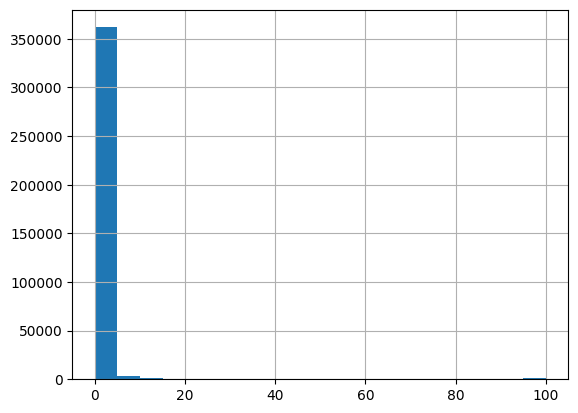

In [20]:
risk_df["risk_score"].hist(bins=20)

## Create Risk Categories

## 1. Create Risk Categories

In [28]:
def assign_risk_category(score):
    if score < 5:
        return "Low"
    elif score < 20:
        return "Medium"
    elif score < 50:
        return "High"
    else:
        return "Critical"

## 2. Apply Categories

In [29]:
risk_df["risk_category"] = risk_df["risk_score"].apply(
    assign_risk_category
)

## 3. Verify Output

In [30]:
risk_df.head(10)

,actual_fraud,risk_score,risk_category
0,0,0.0,Low
1,0,0.0,Low
2,0,0.0,Low
3,0,1.0,Low
4,0,0.0,Low
5,0,0.0,Low
6,0,0.0,Low
7,0,0.0,Low
8,0,0.0,Low
9,0,1.0,Low


## 4. Check Category Distribution

In [31]:
risk_df["risk_category"].value_counts()

risk_category
Low         361872
Medium        5587
Critical      1765
High          1255
Name: count, dtype: int64

## 5. Calculate Category Percentage

In [32]:
(
    risk_df["risk_category"]
    .value_counts(normalize=True) * 100
)

risk_category
Low         97.676791
Medium       1.508048
Critical     0.476410
High         0.338751
Name: proportion, dtype: float64

## 6. Visualize Risk Categories

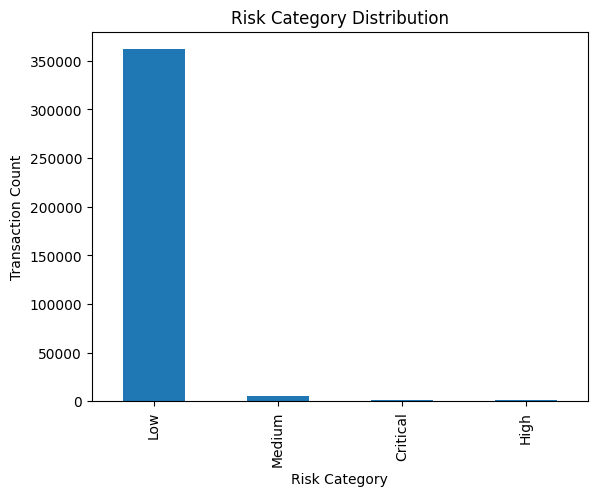

In [33]:
import matplotlib.pyplot as plt

risk_df["risk_category"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Transaction Count")

plt.show()

## Check

In [27]:
risk_df["risk_score"].value_counts().sort_index().tail(30)

risk_score
71.0      18
72.0      13
73.0      16
74.0      18
75.0      15
76.0      21
77.0      18
78.0      22
79.0      17
80.0      20
81.0      24
82.0      23
83.0      21
84.0      18
85.0      27
86.0      32
87.0      28
88.0      29
89.0      38
90.0      37
91.0      33
92.0      54
93.0      62
94.0      62
95.0      73
96.0      79
97.0     113
98.0     133
99.0     166
100.0    240
Name: count, dtype: int64

## Automated fraud alert generation

## 1. Create Alert Generation Function

In [34]:
def generate_alert(category):
    if category == "Critical":
        return "CRITICAL FRAUD ALERT"
    elif category == "High":
        return "HIGH RISK ALERT"
    elif category == "Medium":
        return "MEDIUM RISK ALERT"
    else:
        return "LOW RISK"

## 2. Generate Alerts

In [35]:
risk_df["alert"] = risk_df["risk_category"].apply(
    generate_alert
)

## 3. Verify Output

In [36]:
risk_df.head(10)

,actual_fraud,risk_score,risk_category,alert
0,0,0.0,Low,LOW RISK
1,0,0.0,Low,LOW RISK
2,0,0.0,Low,LOW RISK
3,0,1.0,Low,LOW RISK
4,0,0.0,Low,LOW RISK
5,0,0.0,Low,LOW RISK
6,0,0.0,Low,LOW RISK
7,0,0.0,Low,LOW RISK
8,0,0.0,Low,LOW RISK
9,0,1.0,Low,LOW RISK


## 4. Check Alert Distribution

In [37]:
risk_df["alert"].value_counts()

alert
LOW RISK                361872
MEDIUM RISK ALERT         5587
CRITICAL FRAUD ALERT      1765
HIGH RISK ALERT           1255
Name: count, dtype: int64

## 5. Calculate Alert Percentage

In [38]:
(
    risk_df["alert"]
    .value_counts(normalize=True) * 100
)

alert
LOW RISK                97.676791
MEDIUM RISK ALERT        1.508048
CRITICAL FRAUD ALERT     0.476410
HIGH RISK ALERT          0.338751
Name: proportion, dtype: float64

## 6. View Critical Alerts

In [39]:
risk_df[
    risk_df["alert"] == "CRITICAL FRAUD ALERT"
].head(20)

,actual_fraud,risk_score,risk_category,alert
356,1,91.0,Critical,CRITICAL FRAUD ALERT
664,1,69.0,Critical,CRITICAL FRAUD ALERT
838,1,65.0,Critical,CRITICAL FRAUD ALERT
979,1,99.0,Critical,CRITICAL FRAUD ALERT
1065,1,100.0,Critical,CRITICAL FRAUD ALERT
1072,1,95.0,Critical,CRITICAL FRAUD ALERT
1555,1,88.0,Critical,CRITICAL FRAUD ALERT
1925,1,98.0,Critical,CRITICAL FRAUD ALERT
1954,1,100.0,Critical,CRITICAL FRAUD ALERT
2192,1,100.0,Critical,CRITICAL FRAUD ALERT


## 7. View High Risk Alerts

In [40]:
risk_df[
    risk_df["alert"] == "HIGH RISK ALERT"
].head(20)

,actual_fraud,risk_score,risk_category,alert
143,0,34.0,High,HIGH RISK ALERT
162,0,36.0,High,HIGH RISK ALERT
343,0,48.0,High,HIGH RISK ALERT
592,0,27.0,High,HIGH RISK ALERT
907,0,21.0,High,HIGH RISK ALERT
1092,0,23.0,High,HIGH RISK ALERT
1177,1,21.0,High,HIGH RISK ALERT
1527,1,44.0,High,HIGH RISK ALERT
1758,0,28.0,High,HIGH RISK ALERT
2140,0,34.0,High,HIGH RISK ALERT


## 8. Save Final Risk Dataset

In [41]:
risk_df.to_csv(
    "../datasets/fraud_risk_scores.csv",
    index=False
)